In [32]:
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import cv2

In [33]:
def circle_from_segmentation(image, model):
    res = model(image)
    polygons = res[0].masks.xy
    
    if not polygons or all(len(p) == 0 for p in polygons):
        return None, None

    h, w = image.shape[:2]
    center = np.array([w / 2, h / 2])

    # Gather all polygon points
    all_points = np.concatenate([p for p in polygons if len(p) > 0], axis=0)

    # Find the most distant point from image center
    dists = np.linalg.norm(all_points - center, axis=1)
    sorted_dists = np.sort(dists)[::-1]
    max_dist = sorted_dists[0]

    # If circle goes outside image, use the 5th furthest point instead
    max_possible = min(h, w) / 2
    if max_dist > max_possible and len(sorted_dists) > 5:
        max_dist = sorted_dists[4]  # 5th furthest point (0-indexed)

    # If circle is small (radius < half the min image dimension), add padding
    min_half_dim = min(h, w) / 2
    if max_dist < min_half_dim:
        radius = max_dist * 1.15
    else:
        radius = max_dist

    cx, cy = int(round(center[0])), int(round(center[1]))
    radius = int(round(radius))

    return (cx, cy), radius

def apply_circle_mask(image, center, radius):
    """Black out everything outside the circle."""
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    cv2.circle(mask, center, radius, 255, thickness=-1)  # filled circle
    masked = image.copy()
    masked[mask == 0] = 0
    return masked

def show_images_with_circles(dir, model, n=5, reversed=False):
    images = [f for f in os.listdir(dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    images = sorted(images)
    for i in range(n):
        img_path = os.path.join(dir, images[i])
        img = cv2.imread(img_path)
        if reversed:
            img = img.max() - img
        
        center, radius = circle_from_segmentation(img, model)
        
        if center is not None and radius is not None:
            # Draw circle outline for visualization
            img_with_circle = img.copy()
            cv2.circle(img_with_circle, center, radius, (0, 255, 0), 2)
            
            # Apply the circular mask
            clipped = apply_circle_mask(img, center, radius)
        else:
            img_with_circle = img
            clipped = img

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(cv2.cvtColor(img_with_circle, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'Circle overlay\n{img_path}')
        axes[0].axis('off')
        
        axes[1].imshow(cv2.cvtColor(clipped, cv2.COLOR_BGR2RGB))
        axes[1].set_title('Clipped (black outside circle)')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

In [34]:
input_dir = "./data/black_larva/frames/"


In [35]:
model = YOLO("/Users/caglayantuna/larva_codes/my_codes/yolo_run_size_1048/segment/train/weights/best.pt")

0: 864x1056 33 larvas, 725.0ms
Speed: 48.7ms preprocess, 725.0ms inference, 151.6ms postprocess per image at shape (1, 3, 864, 1056)


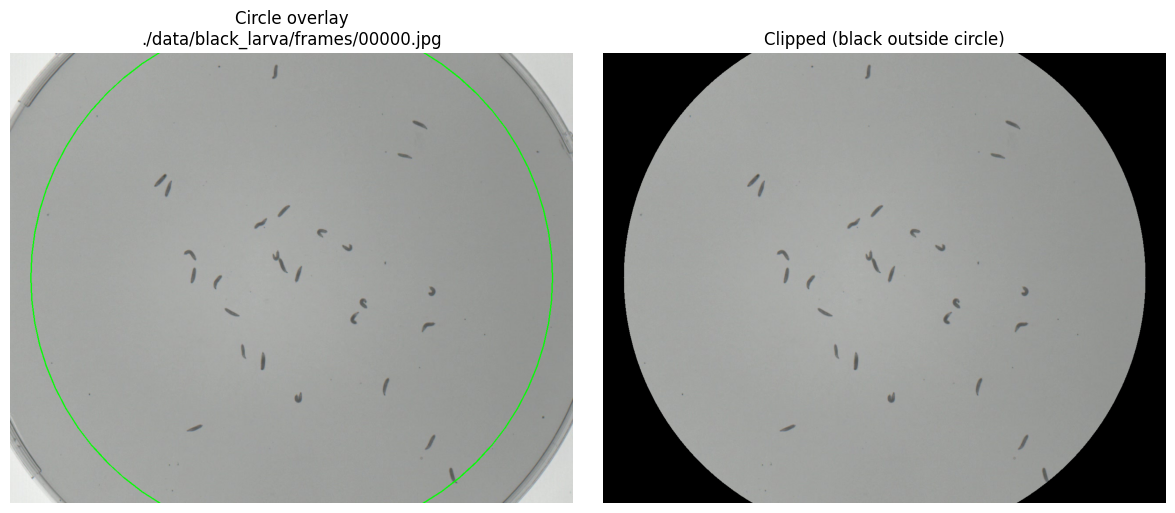


0: 864x1056 33 larvas, 516.5ms
Speed: 138.6ms preprocess, 516.5ms inference, 272.2ms postprocess per image at shape (1, 3, 864, 1056)


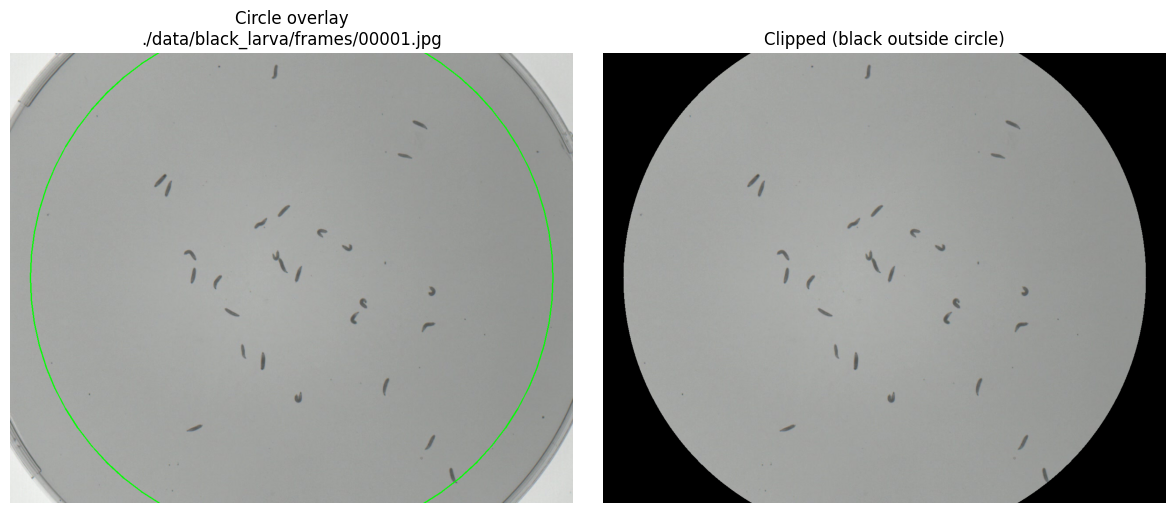


0: 864x1056 33 larvas, 951.0ms
Speed: 119.9ms preprocess, 951.0ms inference, 189.6ms postprocess per image at shape (1, 3, 864, 1056)


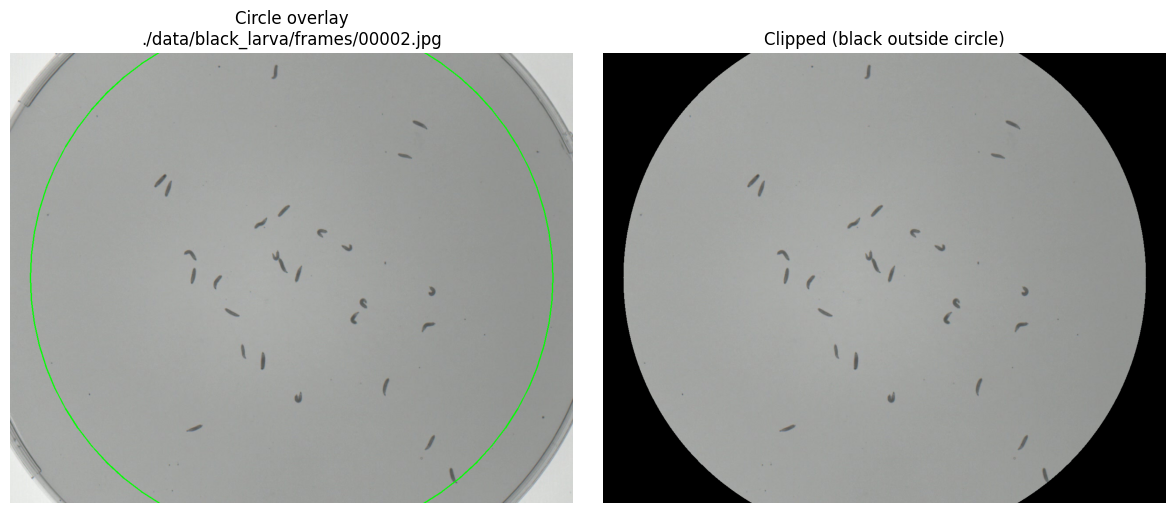


0: 864x1056 32 larvas, 511.7ms
Speed: 48.6ms preprocess, 511.7ms inference, 188.6ms postprocess per image at shape (1, 3, 864, 1056)


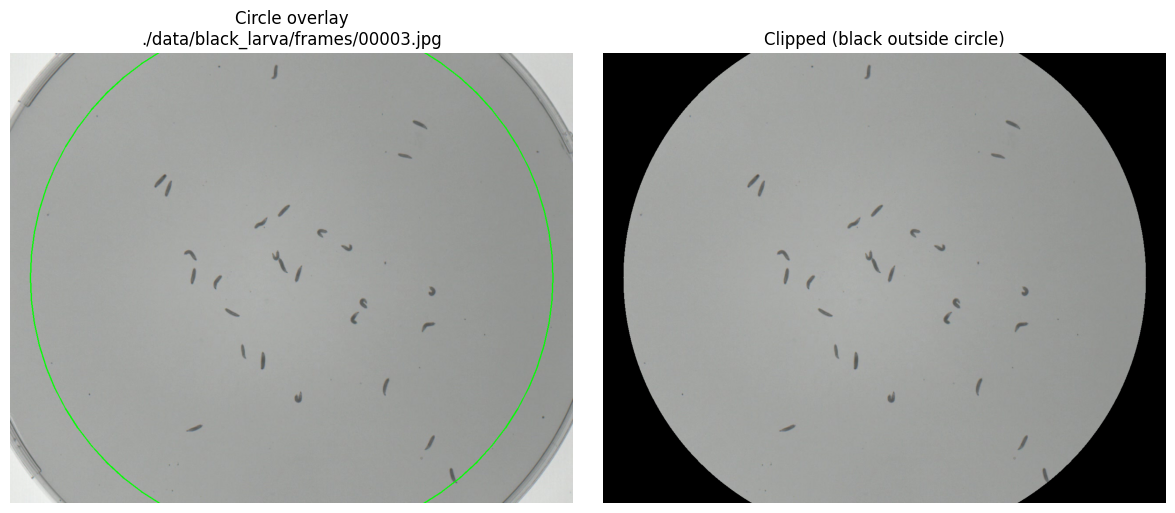


0: 864x1056 33 larvas, 565.3ms
Speed: 12.0ms preprocess, 565.3ms inference, 220.8ms postprocess per image at shape (1, 3, 864, 1056)


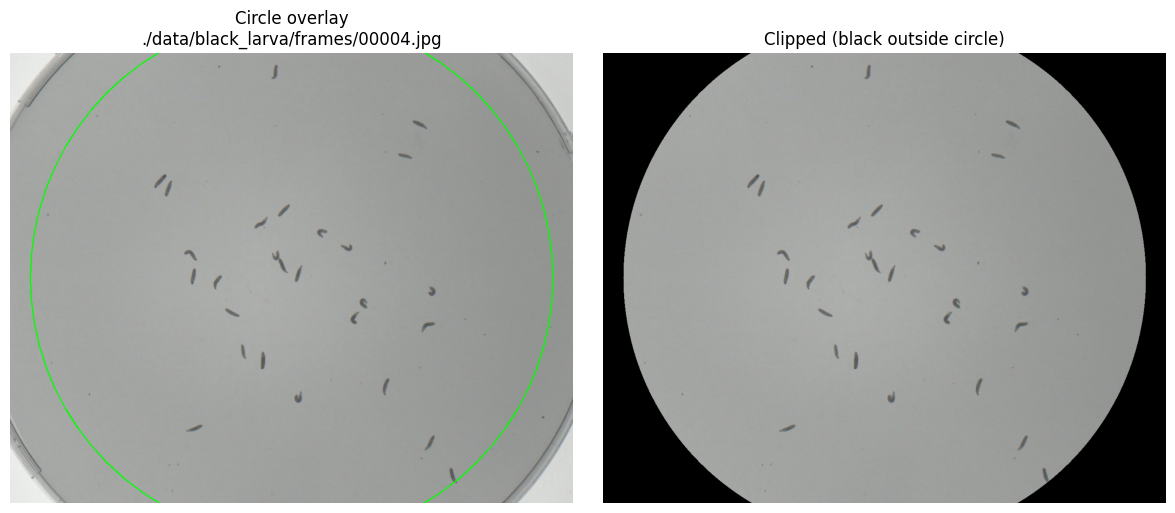

In [36]:
show_images_with_circles(input_dir, model, n=5)


0: 704x1056 68 larvas, 452.9ms
Speed: 13.1ms preprocess, 452.9ms inference, 458.3ms postprocess per image at shape (1, 3, 704, 1056)


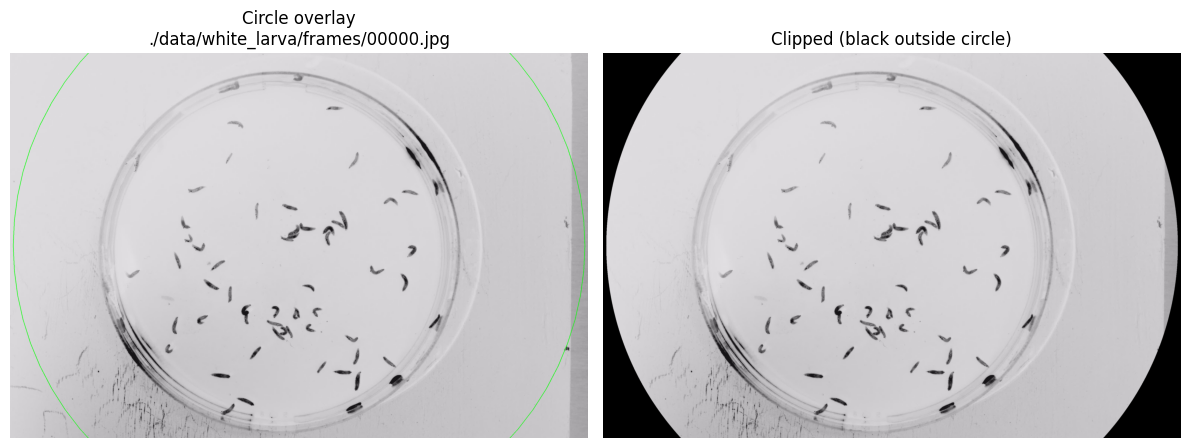


0: 704x1056 73 larvas, 590.0ms
Speed: 33.7ms preprocess, 590.0ms inference, 488.7ms postprocess per image at shape (1, 3, 704, 1056)


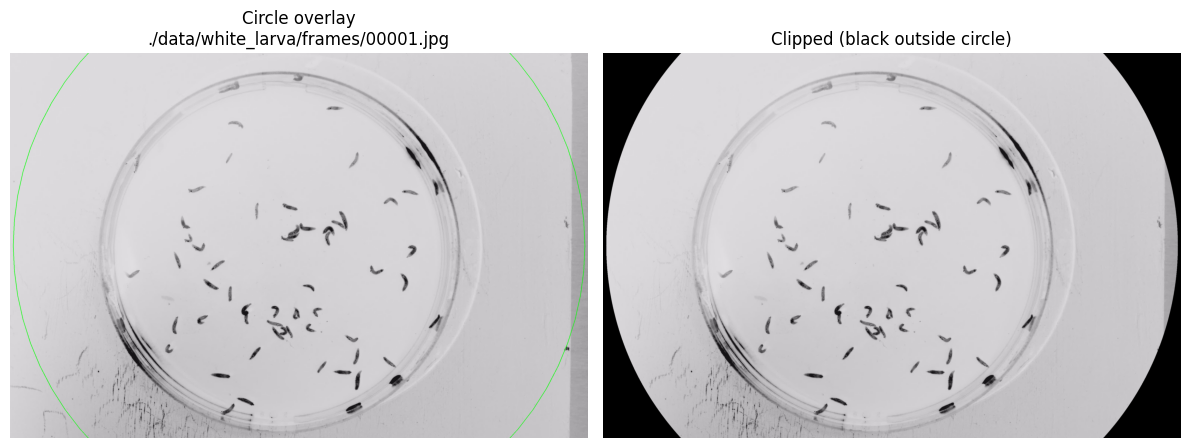


0: 704x1056 76 larvas, 363.1ms
Speed: 12.4ms preprocess, 363.1ms inference, 523.6ms postprocess per image at shape (1, 3, 704, 1056)


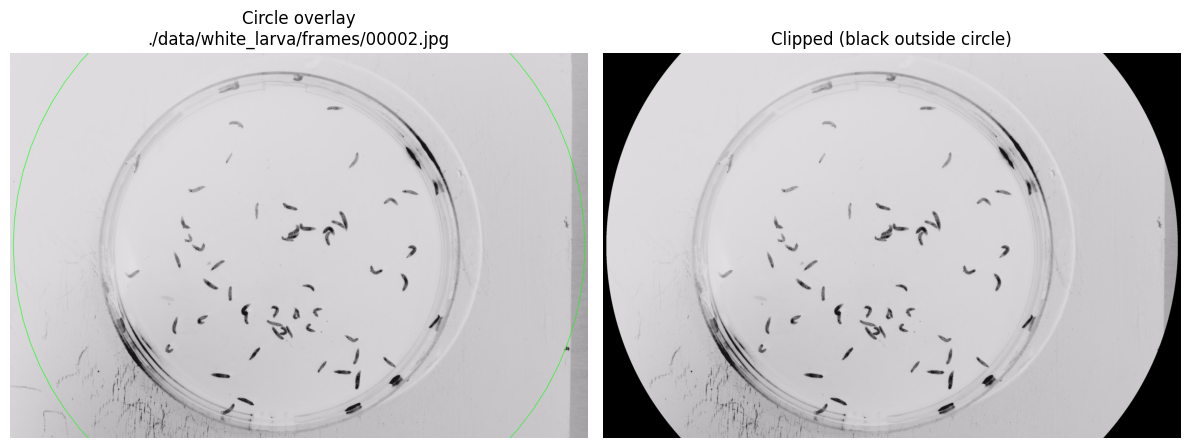


0: 704x1056 76 larvas, 436.8ms
Speed: 38.3ms preprocess, 436.8ms inference, 446.2ms postprocess per image at shape (1, 3, 704, 1056)


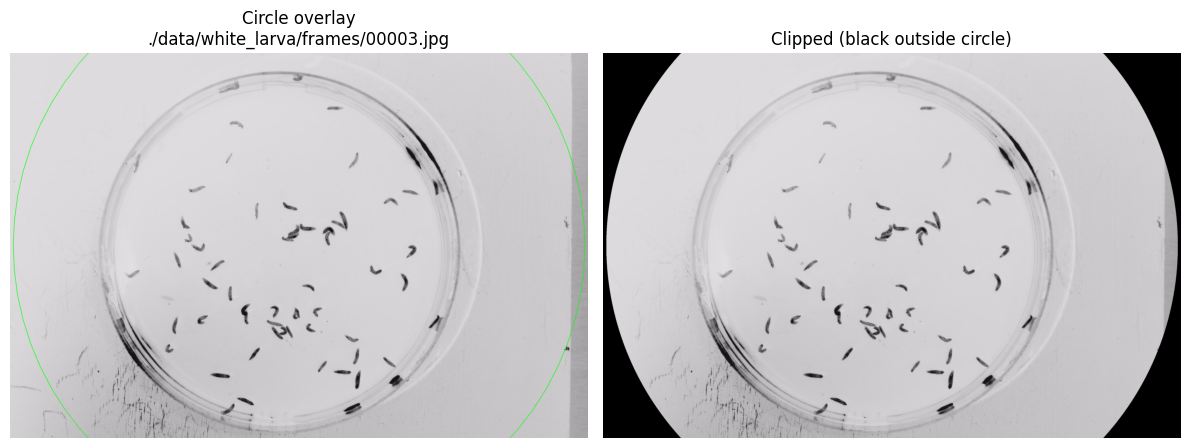


0: 704x1056 69 larvas, 403.9ms
Speed: 26.1ms preprocess, 403.9ms inference, 308.2ms postprocess per image at shape (1, 3, 704, 1056)


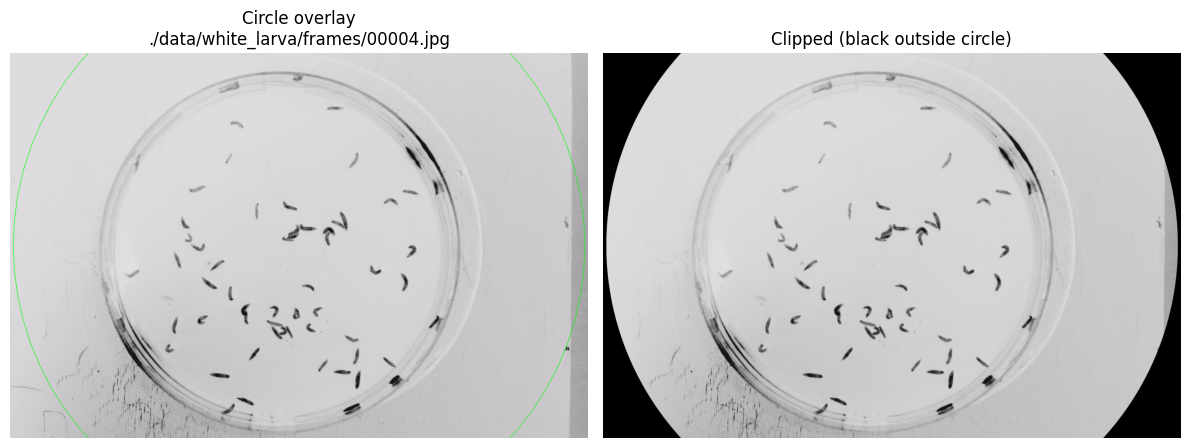

In [37]:

input_dir = "./data/white_larva/frames/"
show_images_with_circles(input_dir, model, n=5, reversed=True)